In [2]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [3]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana2/snert/max/data/amigo_files/"
    data_path = "/media/morgana2/snert/max/data/JWST/IO/calslope/"
else:
    cache = "/Volumes/morgana2/snert/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/IO/calslope/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_states/IO/")

state = np.load(
    os.path.join(model_cache, "conv_up_model.npy"), allow_pickle=True
).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    # "F480M",
    "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [4]:
def truncate_files(files, ngroups):
    """
    Truncate the ramp of files to only have ngroups.
    """
    # TODO do one_on_fs here

    for file in files:

        top_group = file["RAMP"].data.shape[0]
        up_to = top_group - ngroups

        # files are mutable, so they will change in place
        for attr in ["RAMP", "SLOPE", "RAMP_ERR", "RAMP_SUP", "SLOPE_SUP"]:
            file[attr].data = file[attr].data[:-up_to, ...]

        file["SLOPE_ERR"].data = file["SLOPE_ERR"].data[:-up_to, :-up_to, ...]

In [5]:
files = file_fn(data_path)

# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 2236"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
# dorito.misc.truncate_files(sci_files, 18)
truncate_files(sci_files, 18)

In [6]:
import jax.random as jr
from amigo.rnn_models import PixelNonLinearity, ConvRNN, RNNRamp

ramp_model = ConvRNN(key=jr.key(0), use_bias=False, bias_value=1e-3)
ramp_model = RNNRamp(ramp_model, gain_model=PixelNonLinearity())

In [7]:
source_size = 100
# level = 5
# # shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)
# wavelets = dorito.wavelets.Wavelets(
#     np.ones((source_size, source_size)), level=level, wavelet="db2"
# )

model, params, cal_fits, sci_fits = dorito.build_model.build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    # [],
    cal_files[0:2],
    sci_files[0:2],
    # cal_files,
    # sci_files,
    # [],
    state=state,
    modeller=dorito.models.ResolvedAmigoModel,
    ramp_model=ramp_model,
    extra_priors={
        # "approx": np.log10(wavelets.approx),
        # "details": wavelets.values,
        "log_distribution": np.log10(
            np.ones((source_size, source_size)) / source_size**2
        ),
        "spectral_coeffs": np.array([1.0, 0.0]),
    },
    sci_fit=dorito.model_fits.ResolvedFit,
    Teff_cache=teff_cache,
    separate_fits=True,
)
fits = [*cal_fits, *sci_fits]

# # init state
# init_state = np.load(init_state_cache + "F430M.npy", allow_pickle=True)[()]
# for p in [
#     "positions",
#     # "fluxes",
#     "aberrations",
#     # "log_distribution",
# ]:
#     params[p] = init_state[p]
# model = model.set("params", params)

model = model.set("FF", np.load(os.path.join(model_cache, "FF.npy")))
model = model.set(
    "non_linearity", np.load(os.path.join(model_cache, "non_linearities.npy"))
)

/Users/mcha5804/miniconda3/envs/amigo/lib/python3.11/site-packages/astroquery/simbad/core.py:135: UserWarning: Warning: The script line number 2 raised an error (recorded in the `errors` attribute of the result table): 'IO': No known catalog could be found
  warnings.warn("Warning: The script line number %i raised "


No Teff found for IO, defaulting to 4500K


In [8]:
sci_keys = []
for exp in fits:
    if not exp.calibrator:
        sci_keys.append(exp.map_param("positions"))


def kill_pos_grads(model, grads, args):
    grads = grads.multiply(sci_keys, 0.0)
    return grads, args

In [9]:
features = {
    "seth": (-5.35, -131.67),
    "P197": (None, None),
    "masubi": (-49.6, -56.18),
    "leizi": (14.25, -46.16),
    "amirani": (24.46 - 114.68),
}

In [ ]:
rolls[0].

KeyError: 0

In [18]:
files[-1][0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2023-11-04T17:50:38.518' / UTC date file created                     
ORIGIN  = 'STSCI   '           / Organization responsible for creating file     
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw01373017001_04102_00002_0001_nis_calslope.fits' / Name of the file 
SDP_VER = '2023_2a '           / Data processing (DP) Software Version          
PRD_VER = 'PRDOPSSOC-063'      / S&OC Project Reference Database (PRD) Version  
OSS_VER = '008.004.011.000'    / Observatory Scheduling Software (OSS) Version  
GSC_VER = 'GSC2431 '        

In [19]:
from astropy.time import Time

mjd_time = 59792.69710288195
utc_time = Time(mjd_time, format="mjd").iso
print(utc_time)

2022-08-01 16:43:49.689


In [11]:
n_epoch = 40

config = {
    "positions": sgd(2e-1, 0, (25, 1e-16)),
    "fluxes": sgd(2e-1, 0),
    # "fluxes": sgd(5e-1, 2),
    "aberrations": sgd(5e-2, 4),
    "log_distribution": adam(2e-2, 7),  # , (10, 0.25), b1=0.7),
    # "positions": sgd(2e-2, 5),
    # "fluxes": sgd(2e-2, 0),
    # "log_distribution": adam(2e-2, 5),  # , (10, 0.25), b1=0.7),
    # "one_on_fs": sgd(1e2, 6),
    # "approx": adam(1e-5, 0),
    # "approx": adam(6e-3, 8),
    # "details": adam(6e-9, 15),
    # "approx": adam(2e-2, 8),
    # "details": adam(2e-8, 15),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

reg_dict = {
    # "L1": 2.0e3,
    # "L1": 5.0e-4,
    # "L2": None,
    # "TV": None,
    # "QV": 1.0e6,
    # "QV": 1.0e-3,
    # "ME": 1.0e2,
    # "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {
        # "L1": dorito.stats.L1_on_wavelets,
        # "L1": L1_on_wavelets,
        "QV": dorito.stats.TSV,
        "ME": dorito.stats.ME,
    },
    # "mask": mask,
}

trainer = amigo.fitting.Trainer(
    dorito.stats.regularised_loss_fn,
    norm_fn=dorito.stats.normalise_distribution,
    # grad_fn=kill_pos_grads,
    cache=fisher_cache,
)

trainer = trainer.update_fishers(
    model.set("ramp.bleed", False),
    # model,
    fits,
    args=args,
    verbose=True,
    parameters=[
        "positions",
        "fluxes",
        "aberrations",
        # "one_on_fs",
        # "log_distribution",
        # "spectral_coeffs",
    ],
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=fits,
    args=args,
)

# balance = dorito.stats.prior_data_balance(final_model, fits[-1], args)
# print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 120,186,392.50
Estimated run time: 0:03:17
Full Time: 0:03:42
Final Loss: 17,786,635.43


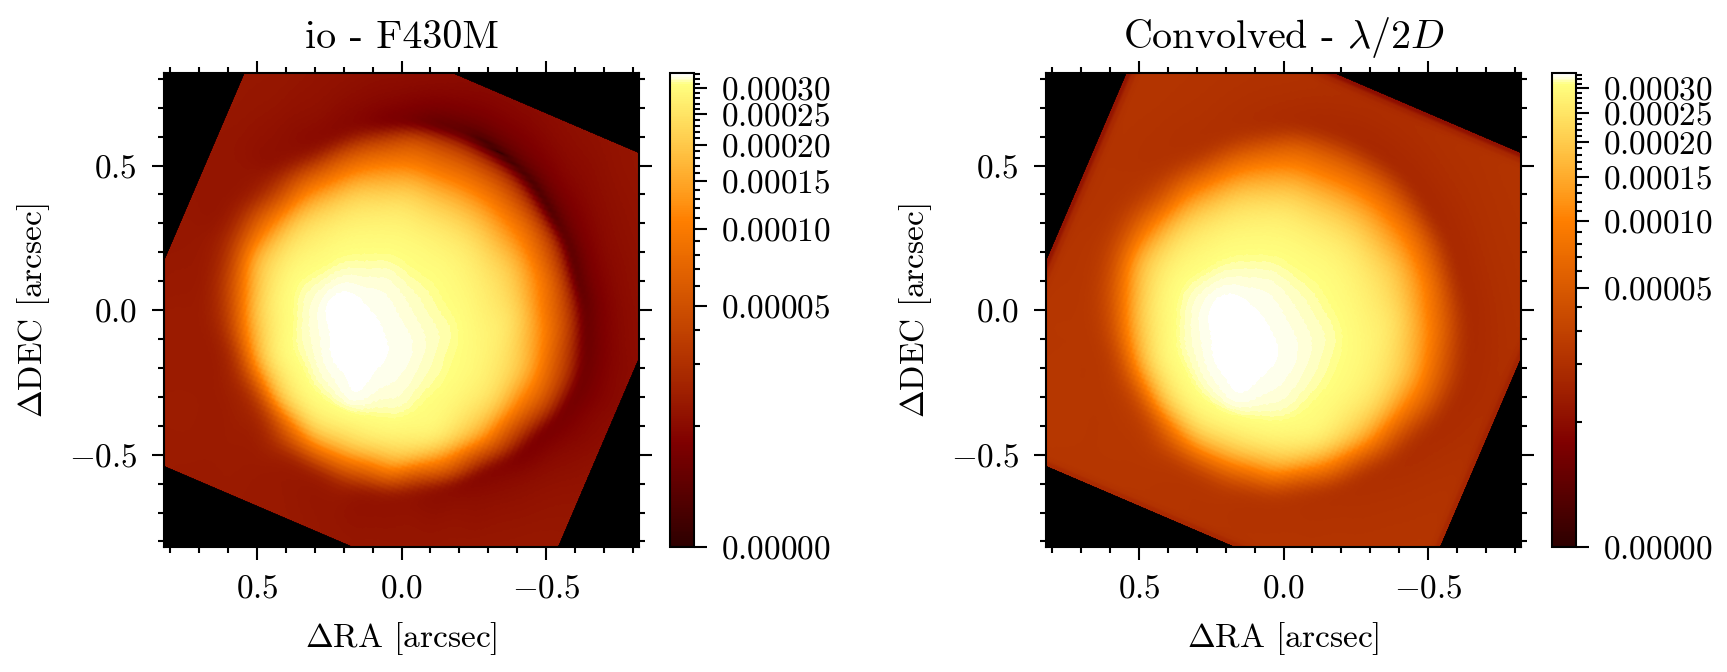

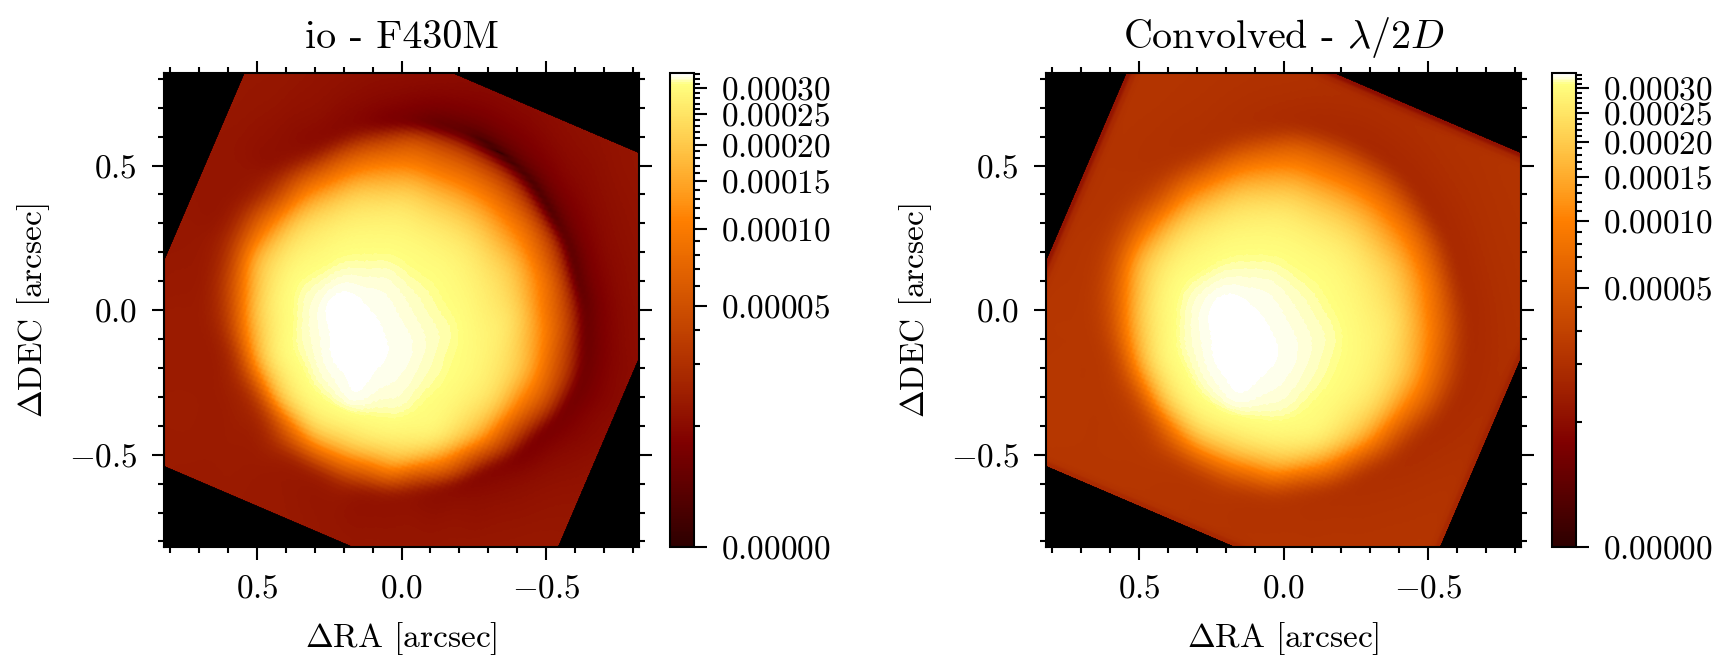

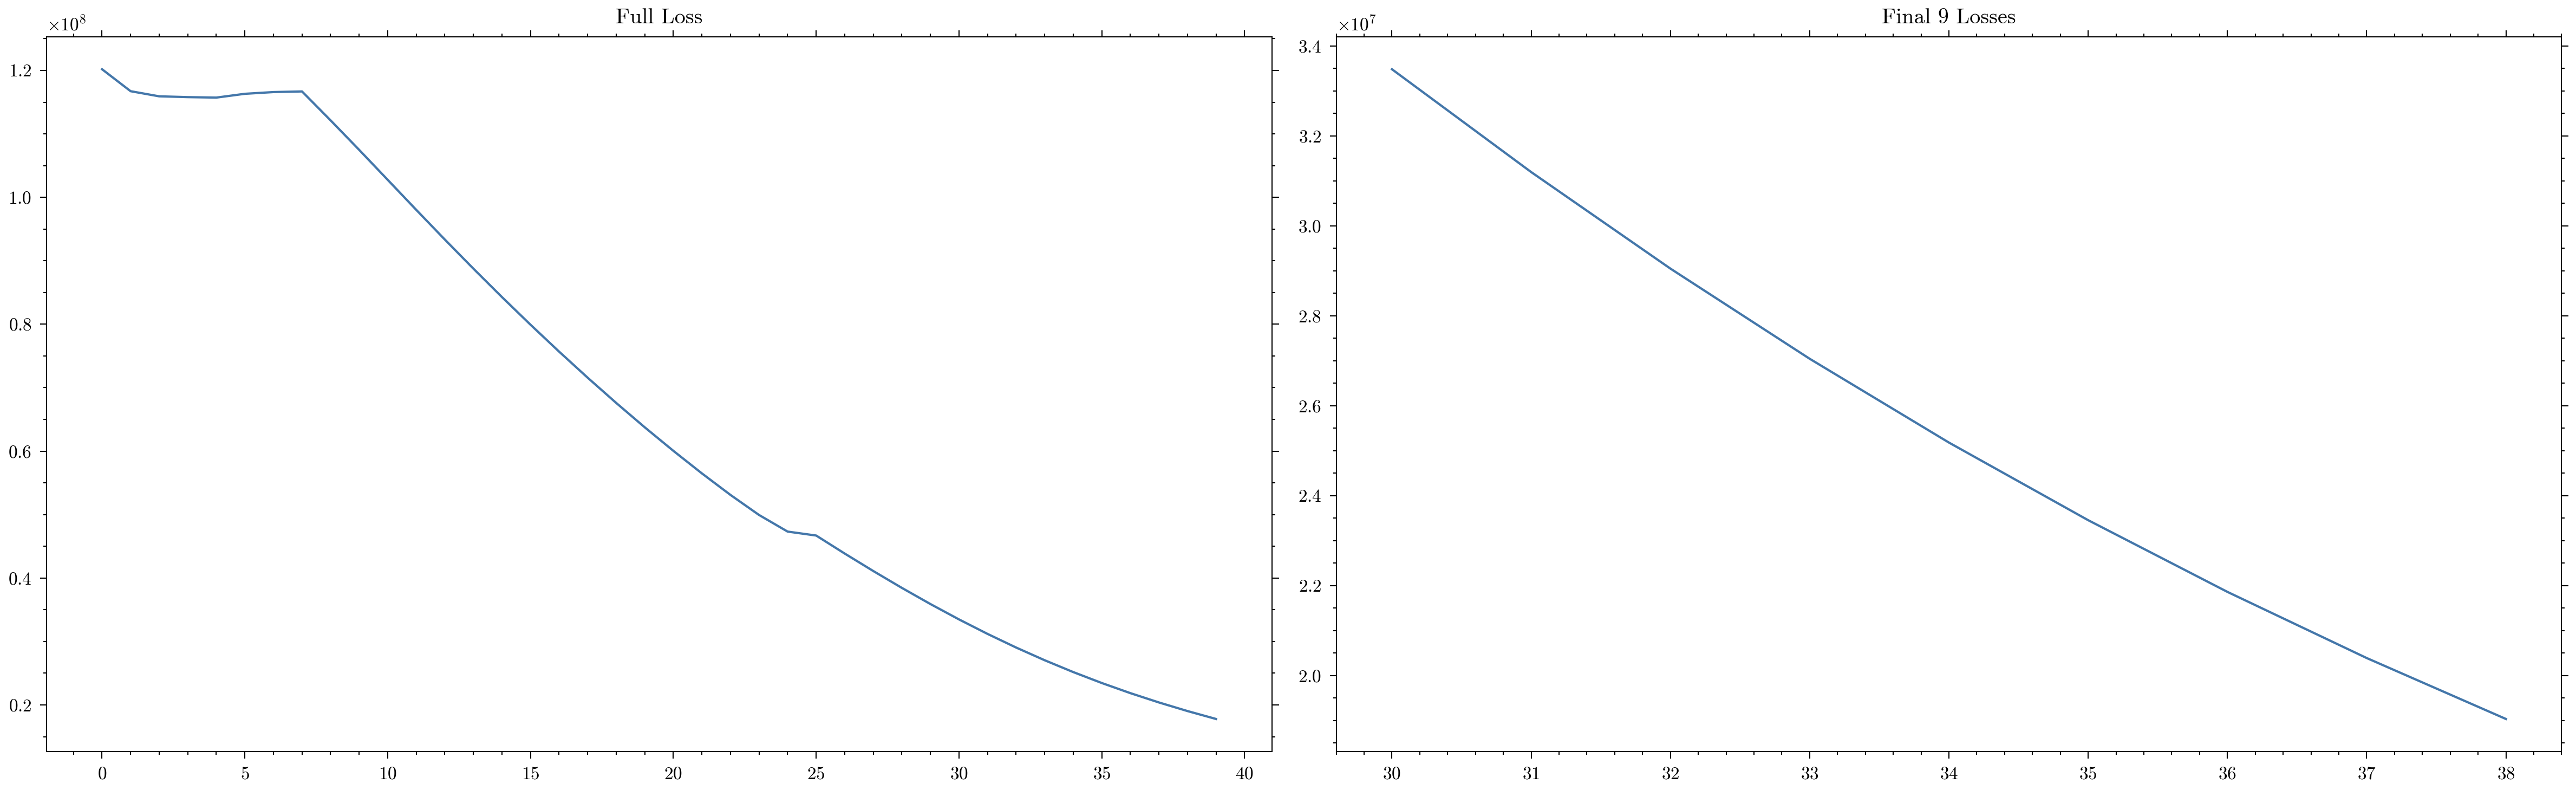

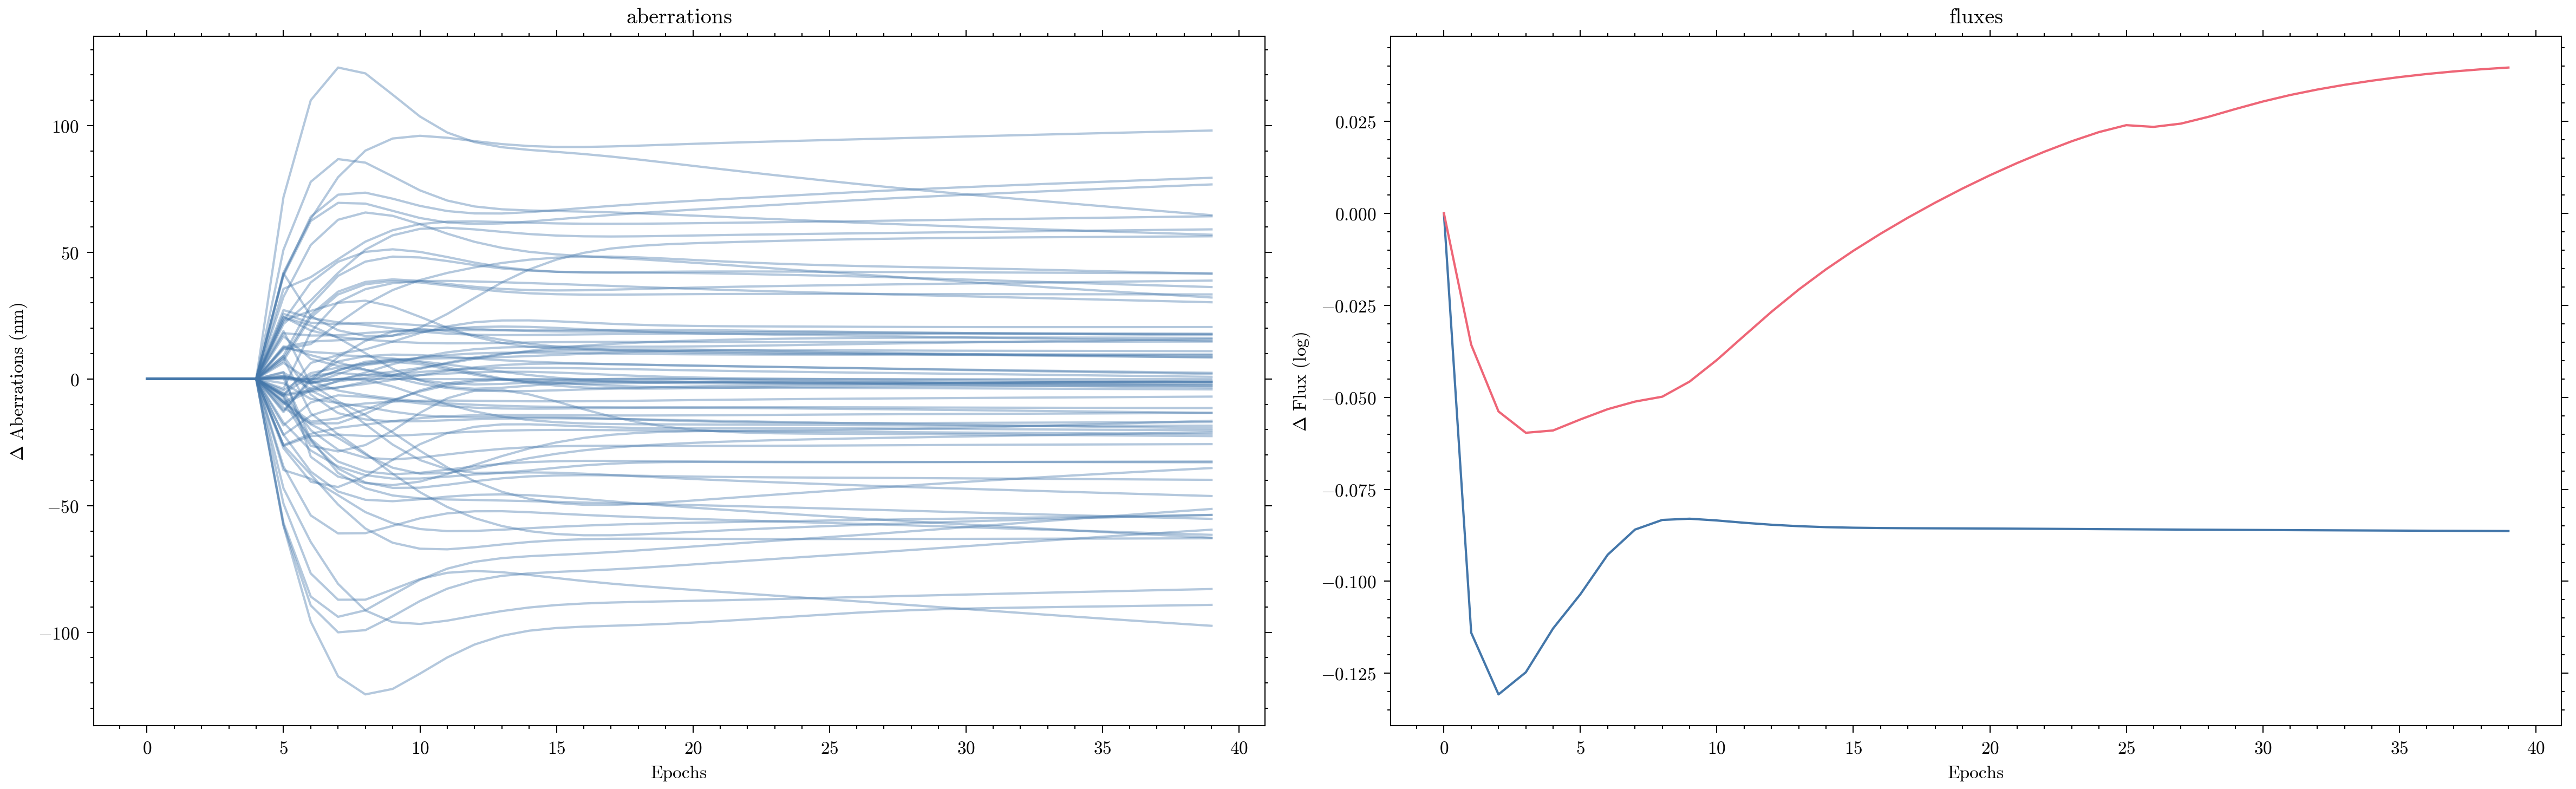

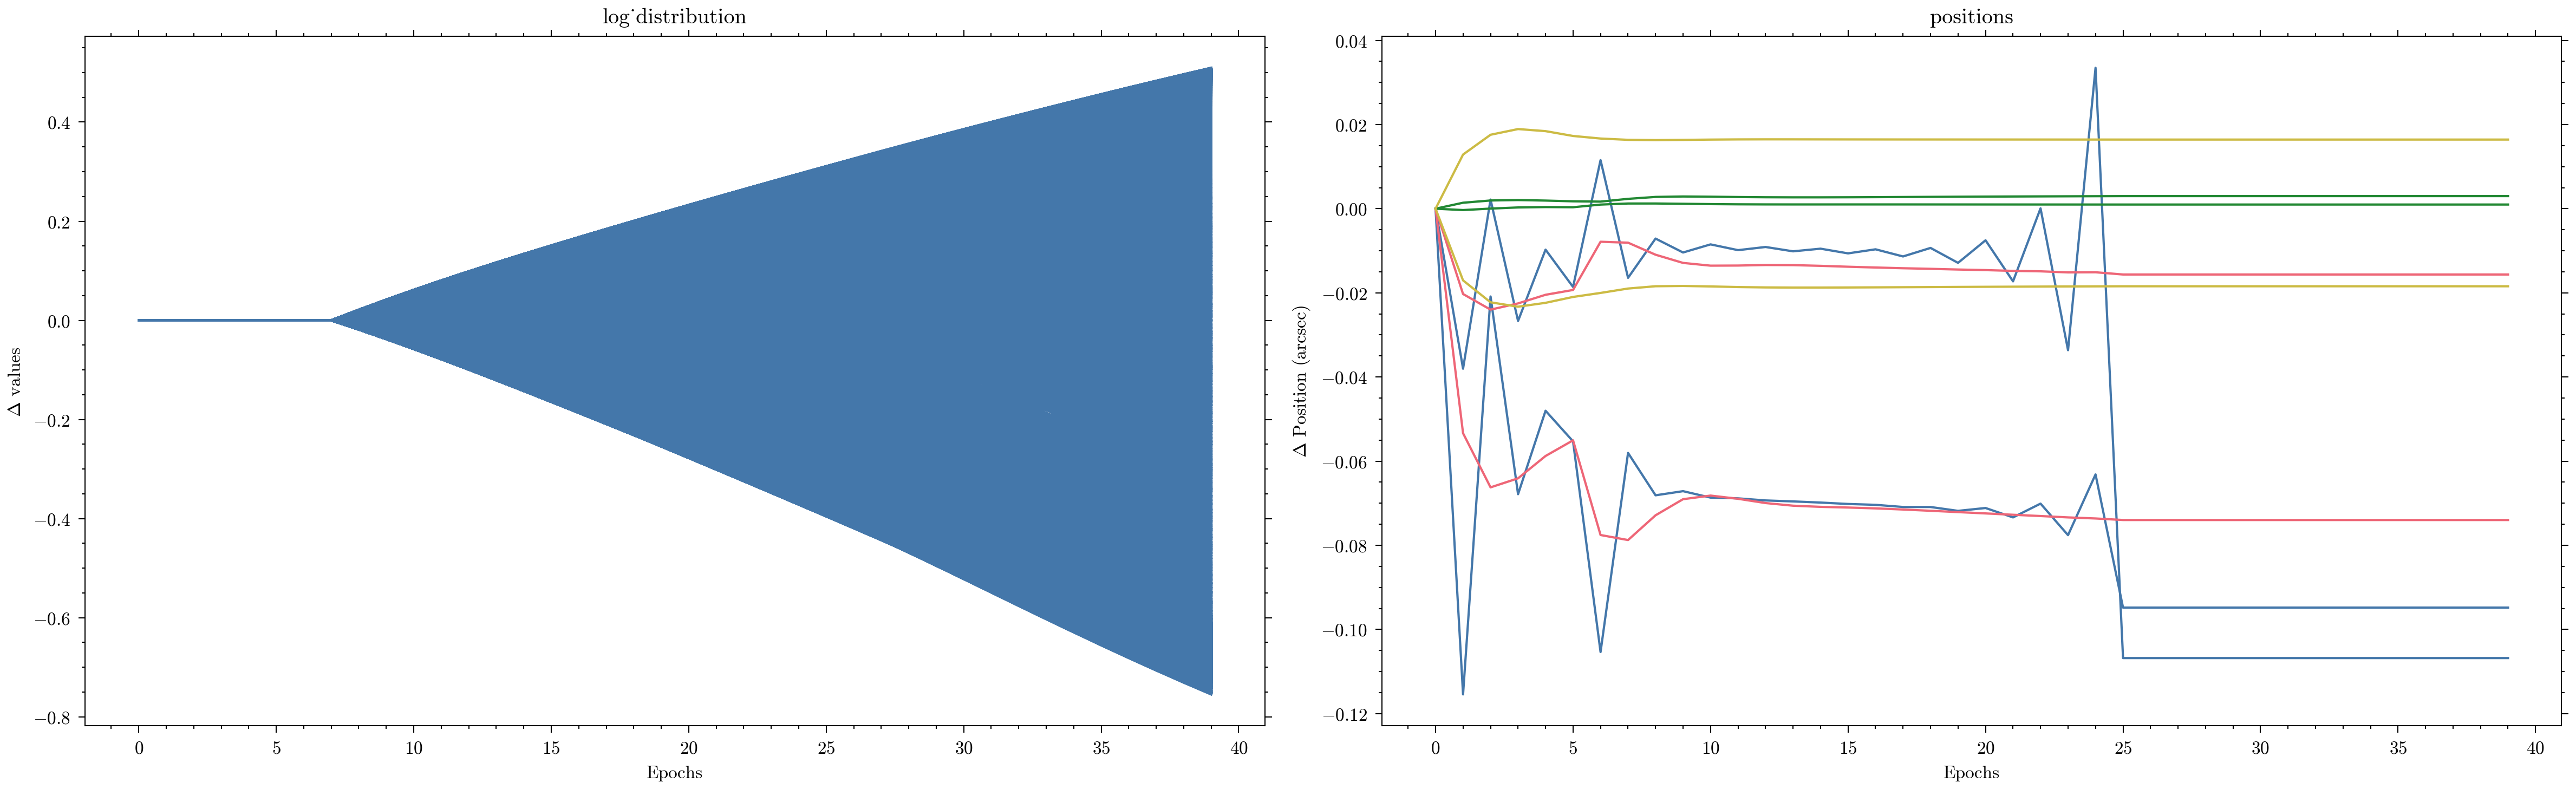

File 01373_023_02_03_3
Star HD 2236
Filter F430M
nints 8
ngroups 12



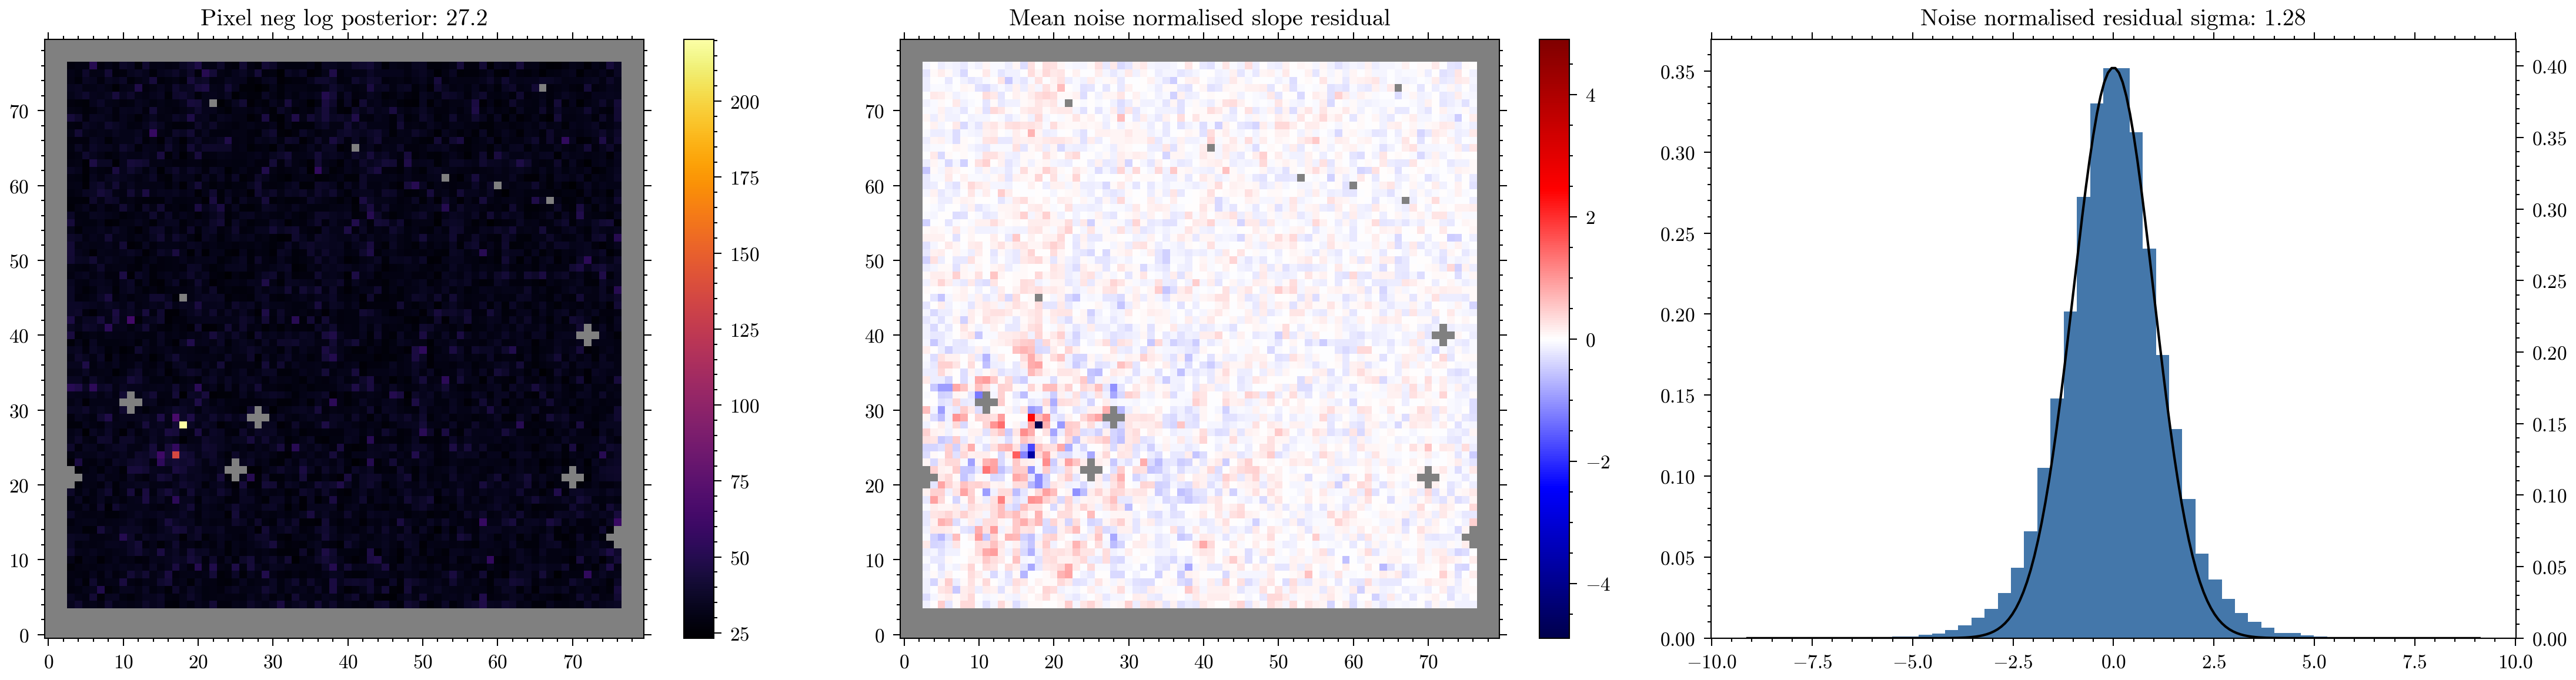

File 01373_023_02_03_4
Star HD 2236
Filter F430M
nints 8
ngroups 12



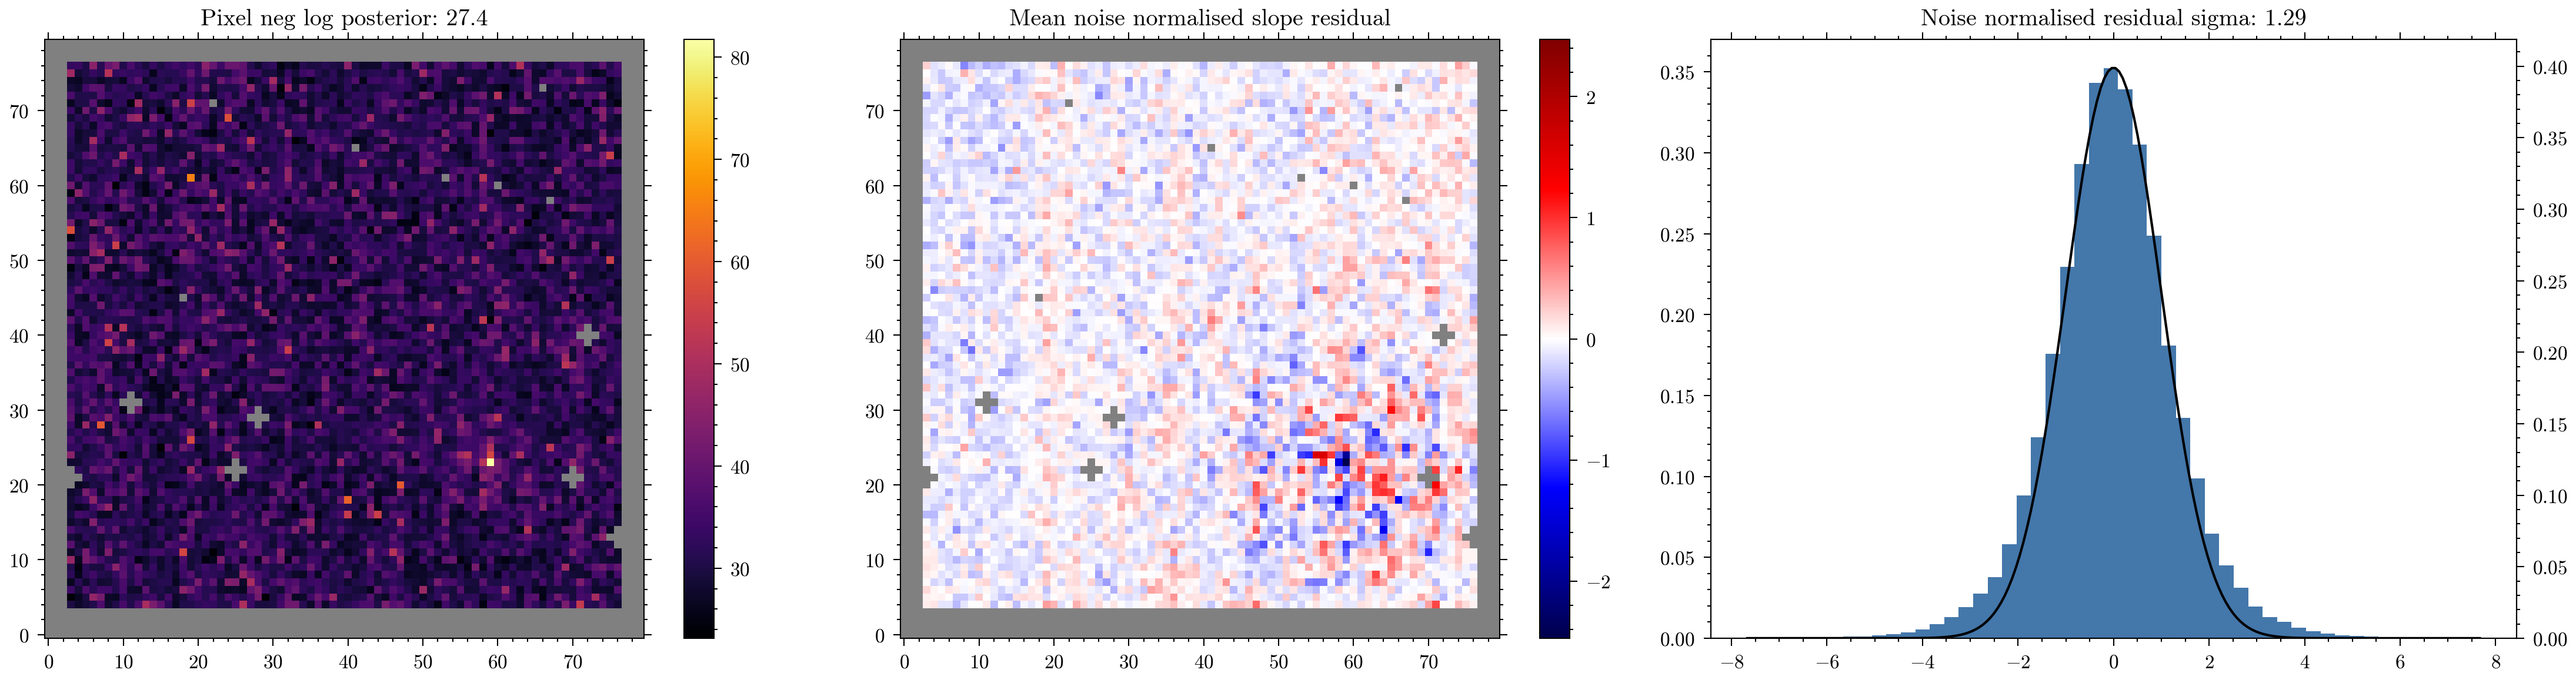

File 01373_017_02_04_3
Star IO
Filter F430M
nints 100
ngroups 18



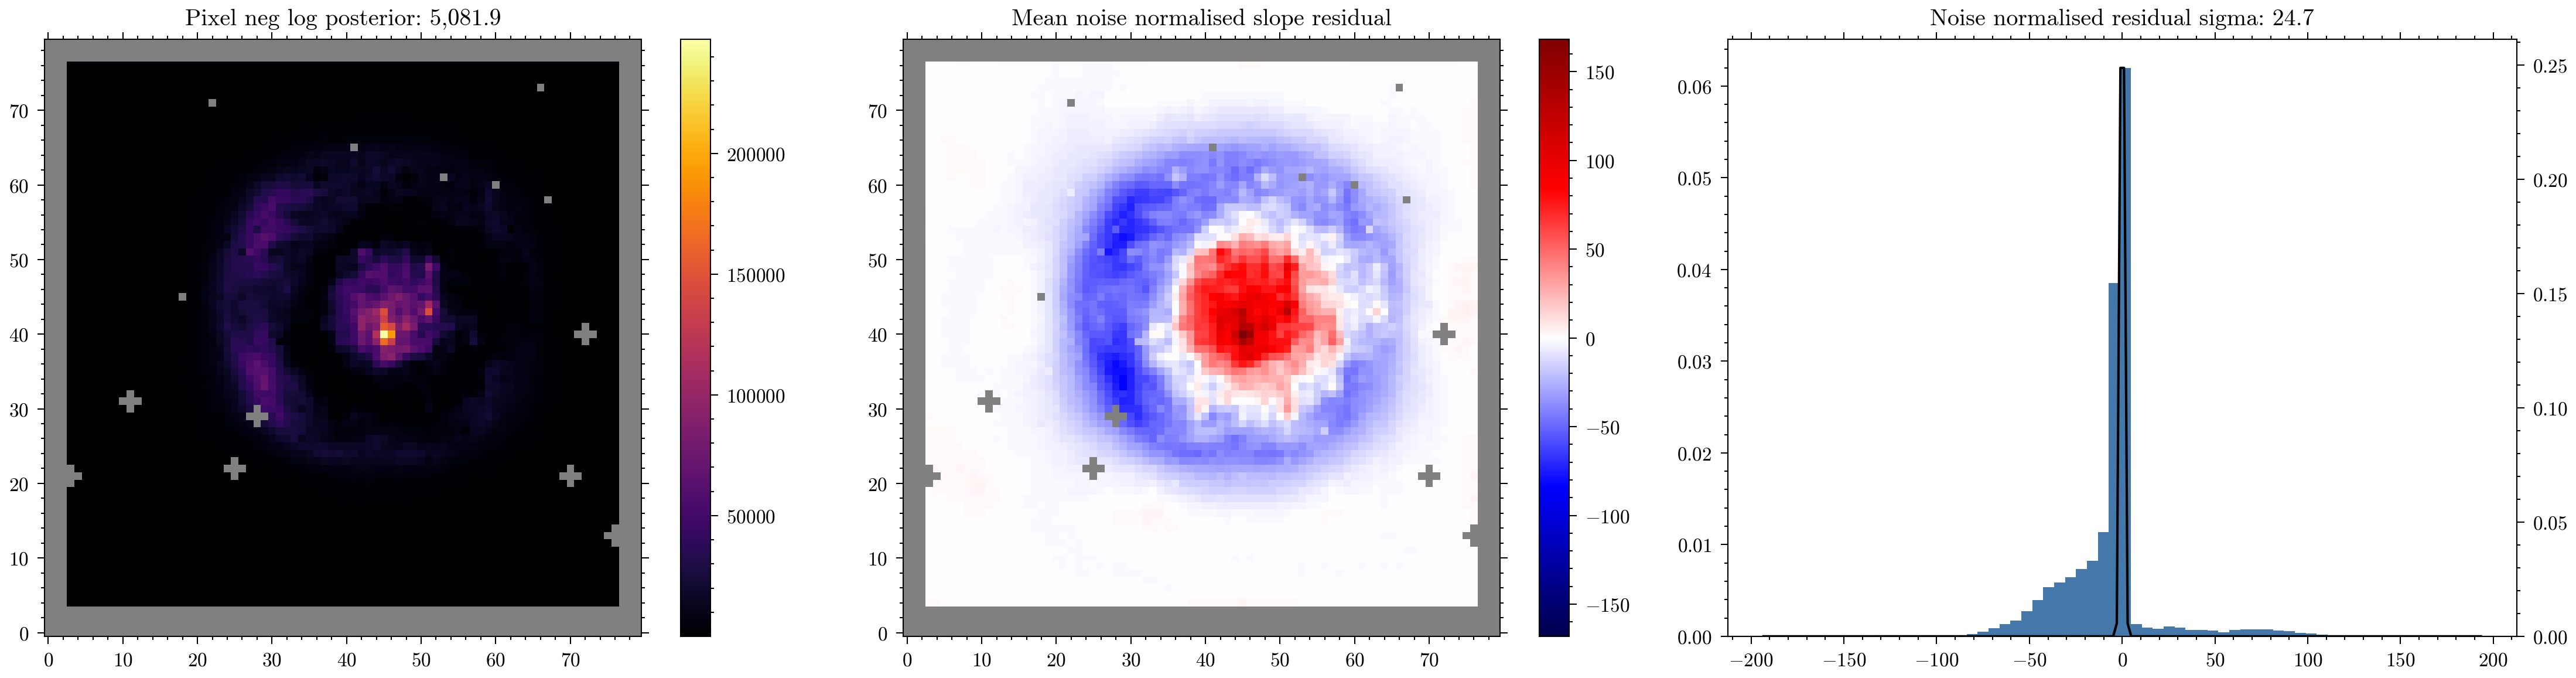

File 01373_017_02_04_4
Star IO
Filter F430M
nints 100
ngroups 18



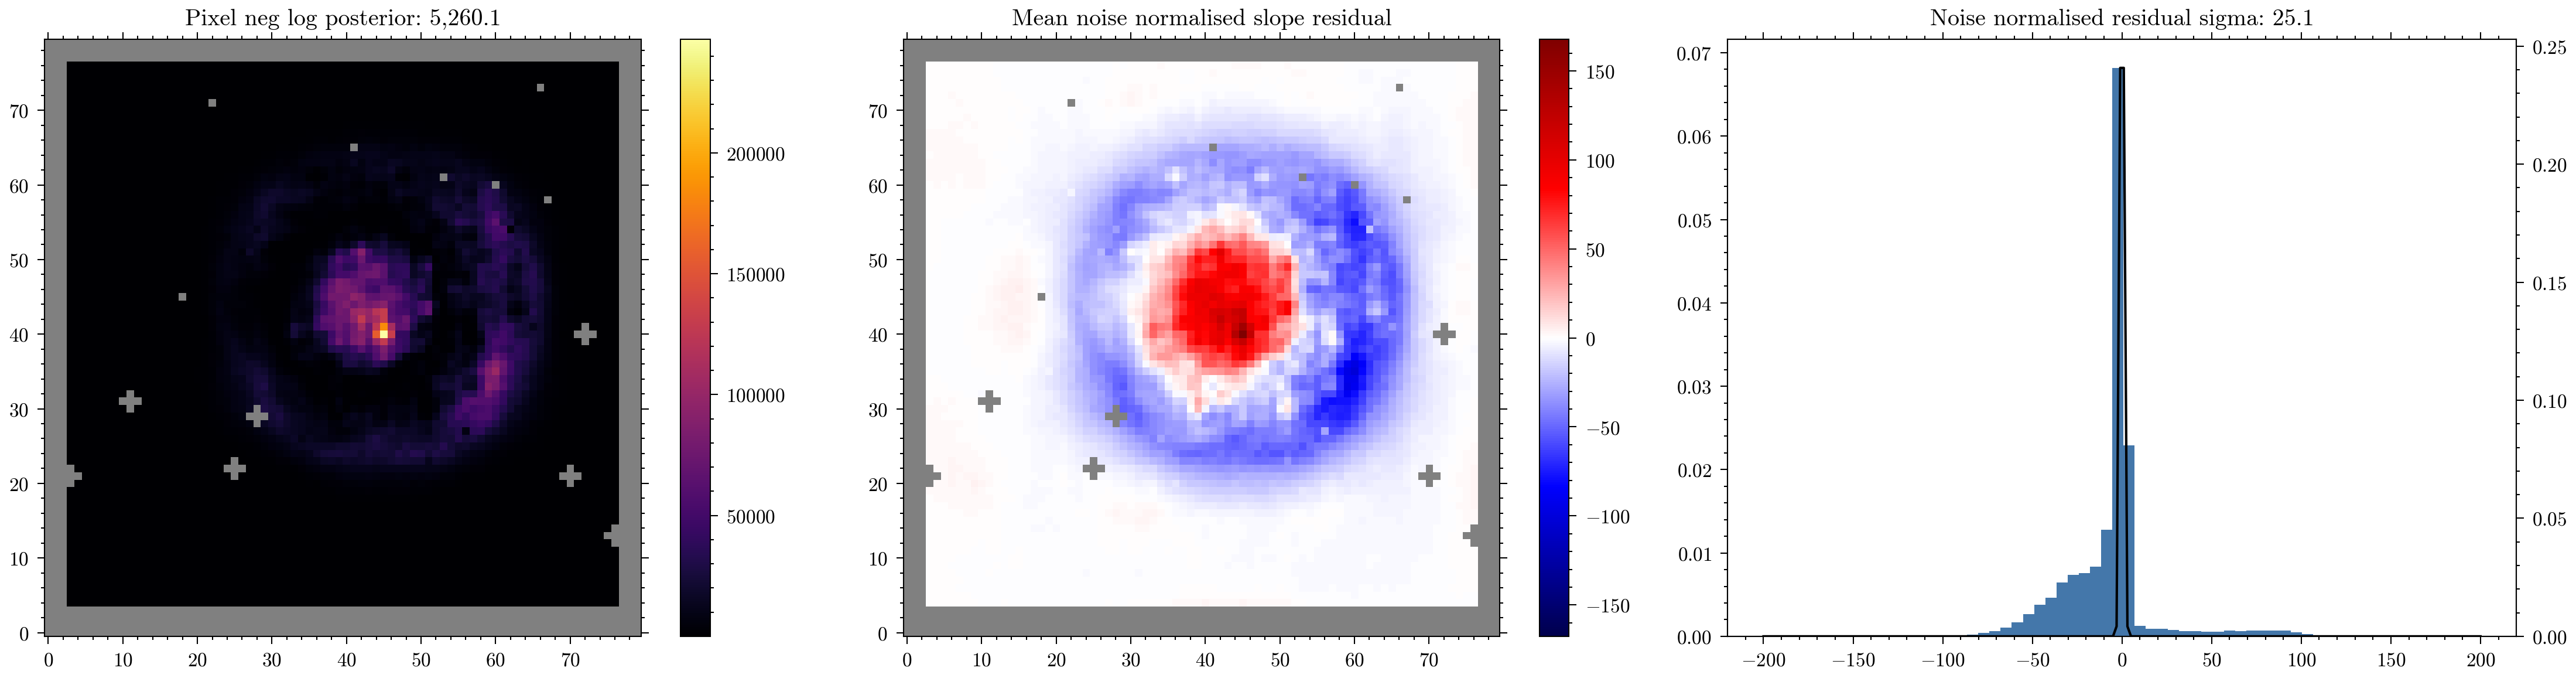

In [14]:
# np.save(init_state_cache + "F430M.npy", state.params)

flag = False
for exp in fits:

    try:
        if not flag:
            try:
                dist = result.model.get_distribution(exp)
            except:
                dist = exp.get_distribution(result.model)

            fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

            c0 = dorito.plotting.plot_result(
                ax[0],
                dist,
                roll_angle_degrees=-rolls[exp.filename],
                cmap="afmhot_10u",
                power=0.3,
                # model=final_model,
                vmin=None,
                # show_diff_lim=True,
                # vmax=io_peak_flux,
            )

            c1 = dorito.plotting.plot_result(
                ax[1],
                dorito.misc.blur_distribution(dist, result.model, exp, factor=0.5),
                cmap="afmhot_10u",
                power=0.3,
                vmin=None,
                roll_angle_degrees=-rolls[exp.filename],
                # model=hdb_final_model,
            )
            fig.colorbar(c1, ax=ax[1])

            fig.colorbar(c0)
            ax[0].set_title(f"io - {exp.filter}")
            ax[1].set(title=r"Convolved - $\lambda / 2D$")

            plt.tight_layout()
            # plt.savefig(save_dir + f"{time}.png", dpi=300)
            # plt.close()
            plt.show()
        # flag = True
    except:
        continue

amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(
        result.model,
        exp,
        # test_model,
    )

In [13]:
# plotting_io_comparison(
#     sci_final_model,
#     initial_distribution=10**initial_sci_model.log_distribution,
#     # roll_angle_degrees=roll_angle,
#     save=None,
#     cmap="afmhot_u",
#     eph_cmap="bone_ur",
#     io_max=(10 ** sci_final_model.log_distribution).max(),
#     power=0.8,
#     eph_power=1.,
# )
import astropy

io_peak_flux = np.array(
    [10 ** sci_final_model.log_distribution[exp.key] for exp in sci_exposures]
).max()

save_dir = "gifs/spinning_io/"
for exp, file in zip(sci_exposures, sci_files):

    time = astropy.time.Time(files[0][0].header["EXPMID"], format="mjd").isot

    # plt.figure(figsize=(7,5))
    # plt.title(f'Recovered Distribution: {time}')
    # plt.imshow(
    #     10 ** sci_final_model.log_distribution[exp.key],
    #     cmap='afmhot_10u',
    #     interpolation="none",
    #     vmax=0.0045,
    #     )
    # plt.colorbar()
    # # plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.5))
    c0 = plot_io(
        ax[0],
        10 ** sci_final_model.log_distribution[exp.key],
        roll_angle_degrees=roll_angle,
        cmap="afmhot_u",
        vmax=io_peak_flux,
    )
    c1 = plot_io_with_ephemeris(
        ax[1],
        10 ** sci_final_model.log_distribution[exp.key],
        roll_angle_degrees=roll_angle,
        n_volc=0,
        cmap="bone_u",
        date=time,
        vmax=io_peak_flux,
    )

    fig.colorbar(c0)
    ax[0].set_title(f"Io: {time}")
    ax[1].set_title(f"Ephemeris")
    plt.tight_layout()
    # plt.savefig(save_dir + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

NameError: name 'sci_exposures' is not defined